# Macroeconomic Analysis — Eurozone (2000–2023)

**Author:** Rose Fidalgo Amorim  
**Data source:** World Bank Open Data (CSV download, official)  
**Tools:** Python · Pandas · Matplotlib · Seaborn · SQL (SQLite)  

## Objective
Analyse and compare the macroeconomic performance of 5 major Eurozone economies — France, Germany, Spain, Italy and Belgium — across three key indicators: GDP growth, inflation and unemployment, from 2000 to 2023.

## Plan
1. Data Collection — World Bank Open Data (CSV)
2. Data Cleaning & Preparation
3. Key Macroeconomic Statistics (KPIs)
4. GDP Growth Analysis
5. Inflation Analysis
6. Unemployment Analysis
7. Country Performance Summary
8. Cross-Indicator Correlation
9. SQL Queries
10. Summary, Limitations & Policy Implications

## 1. Data Collection - World Bank Open Data (CSV)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sqlite3
import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid") 
plt.rcParams['figure.figsize'] = (10, 5) 

country = ['FRA', 'DEU', 'ESP', 'ITA', 'BEL']
years = [str(y) for y in range(2000, 2024)]

def load_indicator(filename, indicator_name):
    df = pd.read_csv(filename, skiprows=4)
    df = df[df['Country Code'].isin(country)]
    cols = ['Country Name', 'Country Code'] + years
    df = df[cols]
    df = df.melt(id_vars=['Country Name', 'Country Code'], 
                 var_name='year', value_name=indicator_name)
    df['year'] = pd.to_numeric(df['year'])
    return df


gdp = load_indicator("API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_57.csv", "gdp_growth")
inflation = load_indicator("API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_285.csv", "inflation")
unemployment = load_indicator("API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_33398.csv", "unemployment")

# Fusionner les 3 en un seul DataFrame
df = gdp.merge(inflation, on=['Country Name', 'Country Code', 'year'])
df = df.merge(unemployment, on=['Country Name', 'Country Code', 'year'])

# Renommer pour plus de clarté
df = df.rename(columns={'Country Name': 'country', 'Country Code': 'code'})
df = df.sort_values(['country', 'year']).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Countries: {df['country'].unique()}")
df.head(10)

Shape: (120, 6)
Countries: <StringArray>
['Belgium', 'France', 'Germany', 'Italy', 'Spain']
Length: 5, dtype: str


,country,code,year,gdp_growth,inflation,unemployment
0,Belgium,BEL,2000,3.716705,2.544518,6.586
1,Belgium,BEL,2001,1.099604,2.469258,6.178
2,Belgium,BEL,2002,1.706894,1.645214,6.910
3,Belgium,BEL,2003,1.037955,1.588964,7.680
4,Belgium,BEL,2004,3.571207,2.097283,7.363
5,Belgium,BEL,2005,2.321738,2.781433,8.440
6,Belgium,BEL,2006,2.552341,1.791208,8.246
7,Belgium,BEL,2007,3.676925,1.823056,7.459
8,Belgium,BEL,2008,0.446905,4.489444,6.976
9,Belgium,BEL,2009,-1.906441,-0.053146,7.908


## 2. Data Cleaning & Preparation

In [3]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Values")
print(df.duplicated().sum())


print(f"\nDate range: {df['year'].min()} to {df['year'].max()}")



Missing Values
country         0
code            0
year            0
gdp_growth      0
inflation       0
unemployment    0
dtype: int64

Duplicate Values
0

Date range: 2000 to 2023


In [4]:
df[['gdp_growth', 'inflation', 'unemployment']].describe().round(2)

,gdp_growth,inflation,unemployment
count,120.00,120.00,120.00
mean,1.31,2.07,9.44
std,2.85,1.71,4.31
min,-10.94,-0.50,3.07
25%,0.46,1.11,7.33
50%,1.58,1.83,8.47
75%,2.77,2.78,10.40
max,8.93,9.60,26.09


## Data Quality
The World Bank dataset is complete and well-structured for the 5 selected 
countries over 2000–2023 : no missing values and no duplicates were found 
across all 120 observations (5 countries × 24 years).

Descriptive statistics reveal several notable patterns even before analysis:
- GDP growth ranges from -10.94% to +8.93%, suggesting significant economic 
  shocks over the period
- Inflation averages 2.07% — close to the ECB target of 2% — but peaks at 
  9.60%, reflecting the post-COVID surge
- Unemployment shows the widest variation, with a minimum of 3.07% and a 
  maximum of 26.09%, indicating major structural differences across countries

## 3. Key Macroeconomic Statistics (KPIs) 


In [5]:

print("KEY MACROECONOMIC STATISTICS (2000–2023)")

print(f"Countries analysed      : {df['country'].nunique()}")
print(f"Years covered           : {df['year'].min()} – {df['year'].max()}")
print(f"Total observations      : {len(df)}")
print(f"Avg GDP growth          : {df['gdp_growth'].mean():.2f}%")
print(f"Avg inflation           : {df['inflation'].mean():.2f}%")
print(f"Avg unemployment        : {df['unemployment'].mean():.2f}%")
print(f"Worst GDP year (Spain)  : {df['gdp_growth'].min():.2f}% in {df.loc[df['gdp_growth'].idxmin(), 'year']}")
print(f"Peak unemployment       : {df['unemployment'].max():.2f}% (Spain 2013)")

KEY MACROECONOMIC STATISTICS (2000–2023)
Countries analysed      : 5
Years covered           : 2000 – 2023
Total observations      : 120
Avg GDP growth          : 1.31%
Avg inflation           : 2.07%
Avg unemployment        : 9.44%
Worst GDP year (Spain)  : -10.94% in 2020
Peak unemployment       : 26.09% (Spain 2013)


## 4. GDP Growth Analysis
**Question: How did GDP growth evolve, and which countries were most affected by major economic shocks?**

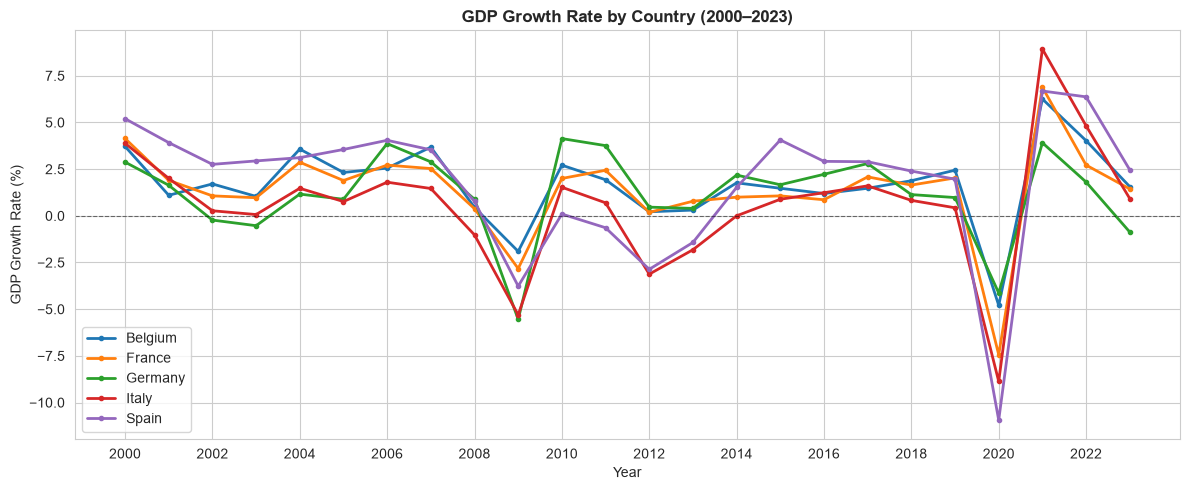

In [6]:
plt.figure(figsize=(12, 5))
for country in df['country'].unique():
    data = df[df['country'] == country]
    plt.plot(data['year'], data['gdp_growth'], label=country,marker='o', markersize=3, linewidth=2)

plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
plt.title("GDP Growth Rate by Country (2000–2023)", fontweight='bold')
plt.xlabel('Year') 
plt.ylabel('GDP Growth Rate (%)') 
plt.xticks(range(2000, 2023, 2))
plt.legend()
plt.tight_layout() 
plt.show()

### Business Insight — GDP
This graph shows that the five Eurozone economies follow broadly similar GDP growth patterns, reflecting their shared monetary policy under the ECB. Two major shocks are clearly visible. In 2009, the financial crisis caused GDP growth to turn negative across all five countries, before recovering in 2010 — though Spain and Italy struggled to return to positive growth for several years. The COVID-19 shock in 2020 was more severe, with Spain recording the steepest contraction, falling below -10%. Germany and Belgium showed greater resilience across both crises, consistently recording higher growth rates than Spain and Italy. 

##5. Inflation Analysis

**Question: How did inflation evolve, and what does the 2022 surge reveal about Eurozone divergence?**

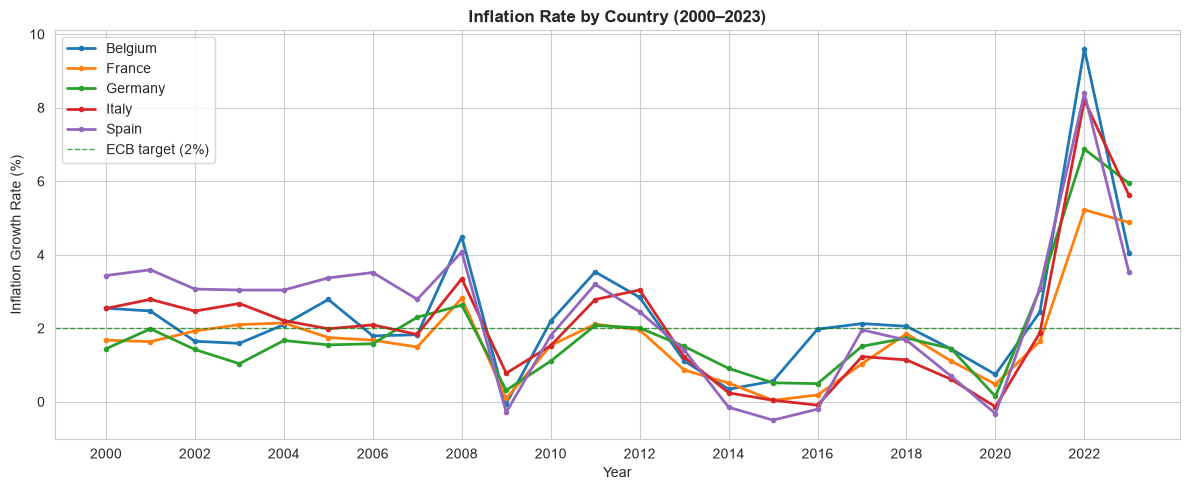

In [7]:
plt.figure(figsize=(12, 5))
for country in df['country'].unique():
    data = df[df['country'] == country]
    plt.plot(data['year'], data['inflation'], label=country, marker='o', markersize=3, linewidth=2)

plt.axhline(y=2, color='green', linestyle='--', linewidth=1,alpha=0.7,label='ECB target (2%)')
plt.title("Inflation Rate by Country (2000–2023)", fontweight='bold')
plt.xlabel('Year') 
plt.ylabel('Inflation Growth Rate (%)') 
plt.xticks(range(2000, 2023, 2))
plt.legend()
plt.tight_layout() 
plt.show()

### Business Insight - Inflation


This graph reveals that despite sharing the same monetary policy under the ECB, inflation dynamics diverge significantly across Eurozone countries, reflecting differences in national fiscal policies and economic structures. Between 2009 and 2020, most countries remained below the ECB's 2% target, a period of persistently low inflation that challenged the ECB's policy framework. Since 2021, all five economies have experienced a sharp inflation surge driven by post-COVID supply disruptions and energy prices, with Belgium peaking at nearly 10% in 2022, the highest in the sample. France and Germany appear the most stable, consistently remaining closest to the 2% target throughout the period. Spain shows the greatest volatility, oscillating between near-deflation in 2020 and elevated inflation in 2022.

## 6. Unemployment Analysis
**Question: Which countries show structural unemployment, and how did labour markets respond to shocks?**

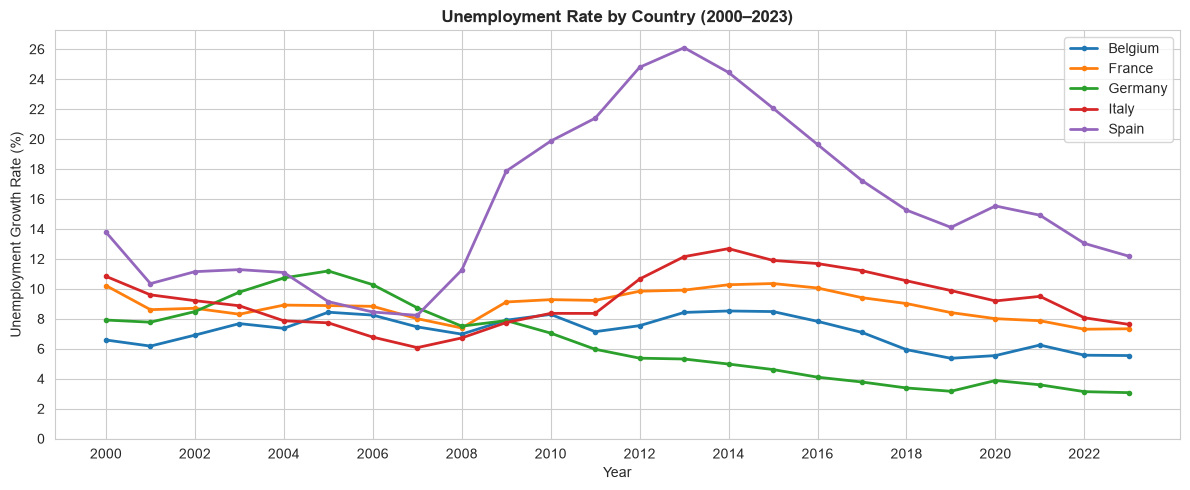

In [8]:
plt.figure(figsize=(12, 5))
for country in df['country'].unique():
    data = df[df['country'] == country]
    plt.plot(data['year'], data['unemployment'], label=country, marker='o', markersize=3, linewidth=2)

plt.title("Unemployment Rate by Country (2000–2023)", fontweight='bold')
plt.xlabel('Year') 
plt.ylabel('Unemployment Growth Rate (%)') 
plt.xticks(range(2000, 2023, 2))
plt.yticks(range(0, 28, 2))
plt.legend()
plt.tight_layout() 
plt.show()

### Business Insight - Unemployment
Spain is the country which struggled the most with the unemployment following the 2008 crisis, reaching a peak of 26% in 2013 before gradually declining, though it remains the highest in the sample throughout the period.
On the contrary, Germany continuously improved its unemployment rate after the 2008 crisis,falling velow 4% in 2016 and in 2020. 
Belgium remained the most stable, with a rate not exceeding 9% over the entire period.
France and Italy show intermediate trajectories : both were affected by the post-2008 shock but recovered more slowly than Germany, with Italy maintaining structurally high unemployment above 10% between 2012 and 2019.

## 7. Country Performance Summary

### 7.1 Average GDP Growth

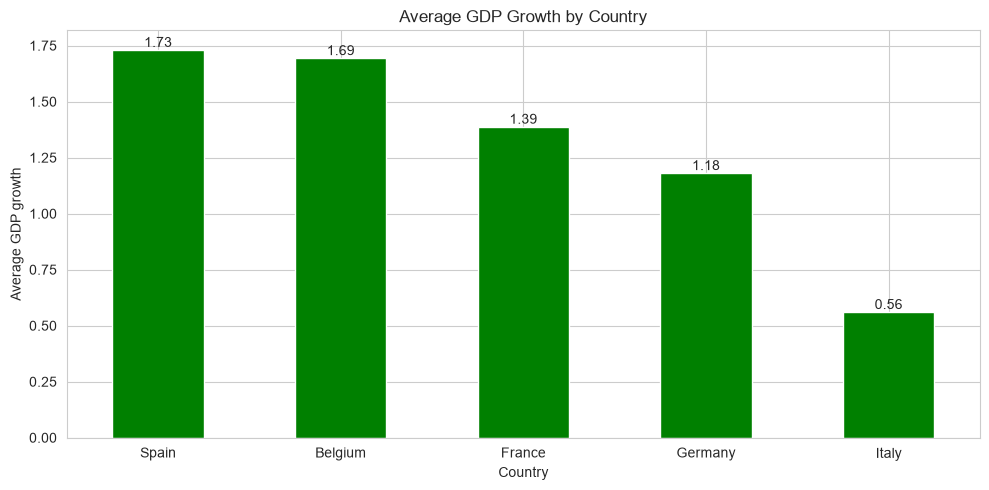

In [9]:
average_gdp=df.groupby("country")["gdp_growth"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
ax=average_gdp.plot(kind="bar", color="Green", edgecolor="white")
plt.title("Average GDP Growth by Country")
plt.ylabel("Average GDP growth")
plt.xlabel("Country")
ax.bar_label(ax.containers[0], fmt="%.2f")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Business Insight
Spain has the highest average GDP growth with 1.73%, followed by Belgium with 1.69%. France and Germany are not really that far but we can notice that Italy's average does not exceed 1%. Italy has the worst average GDP growth

### 7.2 Average Inflation Rate

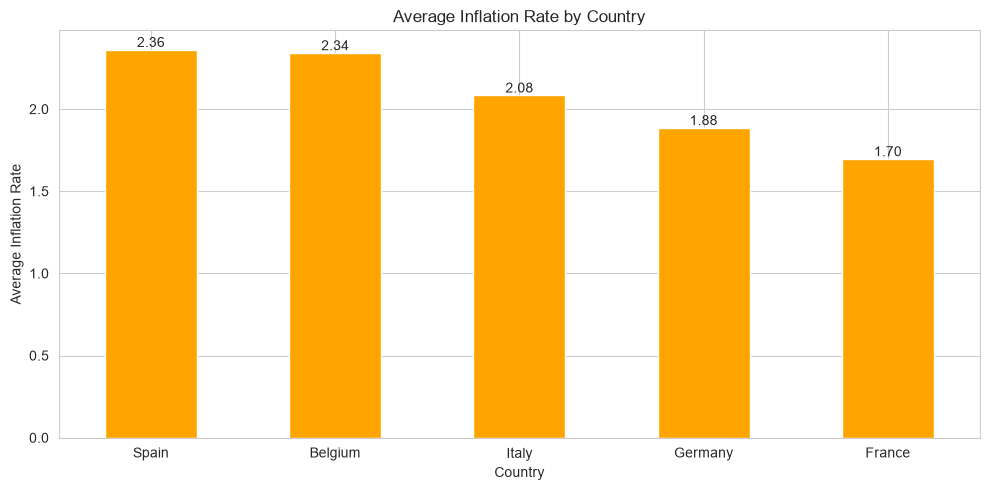

In [10]:
average_inflation=df.groupby("country")["inflation"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
ax = average_inflation.plot(kind="bar", color="orange", edgecolor="white")
plt.title("Average Inflation Rate by Country")
plt.ylabel("Average Inflation Rate")

ax.bar_label(ax.containers[0], fmt="%.2f")
plt.xlabel("Country")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Business Insight
Spain is again at the top but this time is concerning, it has the highest average inflation rate with 2.36%, exceeded the target of the ECB. Belgium and Italy are also above the target with respectively 2.34% and 2.08%. Germany and France have an average rate under the target which suggest differences in economic structures, energy exposure and domestic policy responses

### 7.3 Average Unemployment Rate

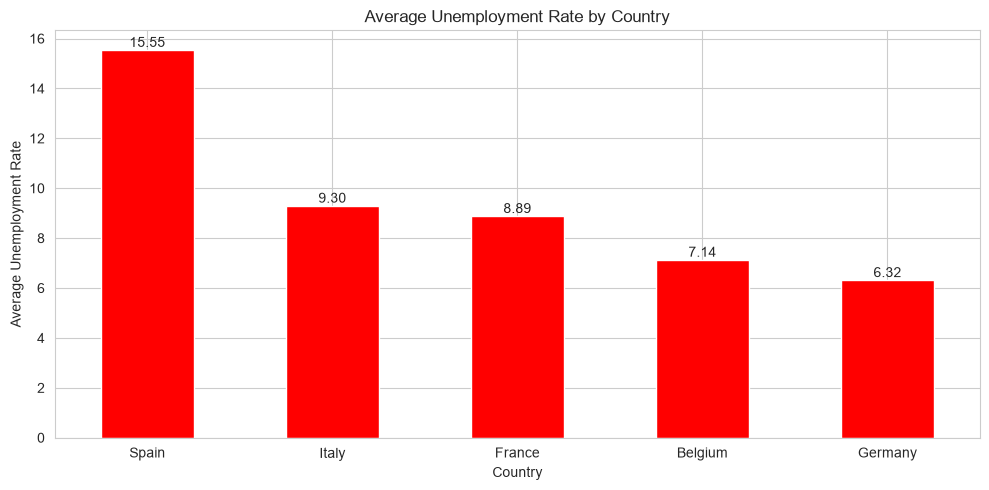

In [11]:
average_unemployment=df.groupby("country")["unemployment"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
ax=average_unemployment.plot(kind="bar", color="red", edgecolor="white")
plt.title("Average Unemployment Rate by Country")
plt.ylabel("Average Unemployment Rate")
plt.xlabel("Country")
ax.bar_label(ax.containers[0], fmt="%.2f")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Business Insight
Spain has the highest average rate of unemployment with 15.55%, almost 10 point of percentage more than Germany, which has the lowest with 6.32%. Therefore we can see that Spain has an extreme rate exceeded 10% while the others do not reach 10%. That suggests Spain struggling unemployment for its citizens. This apparent contradiction between Spain's relatively high average GDP growth and its highest unemployment rate can be explained by the boom-and-bust cycle : strong pre-2008 growth driven by a real estate bubble, followed by a severe post-crisis contraction that generated mass unemployment persisting for over a decade.

## 8. Cross-Indicator Correlation

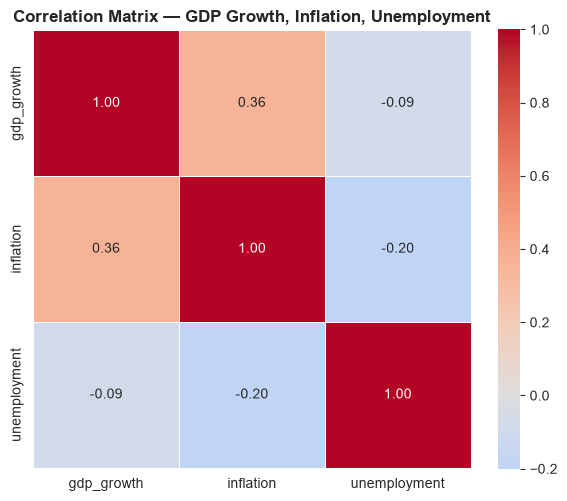

In [12]:
corr = df[['gdp_growth', 'inflation', 'unemployment']].corr().round(2)
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Matrix — GDP Growth, Inflation, Unemployment', 
          fontweight='bold')
plt.tight_layout()
plt.show()

### Business Insight
The positive correlation between GDP growth and inflation suggests that stronger economic activity was often associated with higher inflation, although correlation does not imply causality. The negative correlation between GDP growth and unemployment (-0.09) is weaker than expected under Okun's Law, suggesting that European labour market rigidities delay employment adjustment. Similarly, the weak negative correlation between inflation and unemployment (-0.20) indicates that the Phillips curve relationship is not strongly present in this Eurozone sample over 2000–2023.

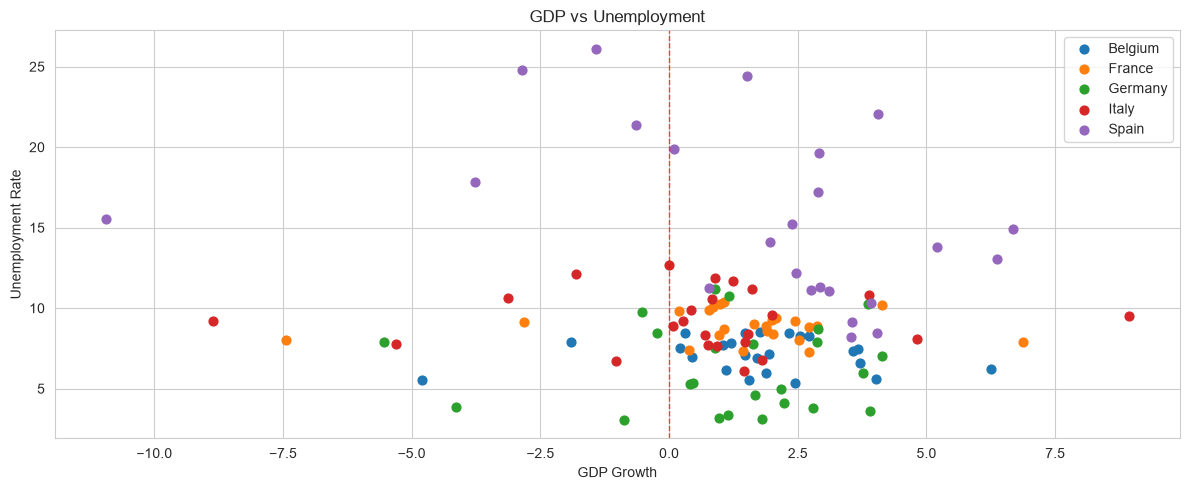

In [13]:
plt.figure(figsize=(12, 5))
for country in df['country'].unique():
    data = df[df['country'] == country]
    plt.scatter(data['gdp_growth'], data['unemployment'], label=country, marker='o', s=40)

plt.title("GDP vs Unemployment")
plt.xlabel("GDP Growth")
plt.ylabel("Unemployment Rate")
plt.axvline(x=0, color='red', linestyle='--', linewidth=1,alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Business Insight
We do not observe a clear correlation between GDP growth and unemployment. Each country maintains a relatively stable unemployment rate regardless of GDP growth, suggesting that structural factors dominate cyclical ones. Spain shows persistent structural unemployment, even when GDP growth is positive, its unemployment rate remains high, between 10% and 25%. On the contrary, Germany maintains an unemployment rate almost always below 10%, reflecting a more flexible and resilient labour market. Belgium, France and Italy show an intermediate situation, with unemployment rates ranging between 5% and 13% regardless of GDP growth

## 9. SQL queries

In [14]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('macro', conn, index=False, if_exists='replace')
print("SQLite database ready")

SQLite database ready


### 9.1 - Average Indicators by Country

In [15]:
query="""
SELECT country,
ROUND(AVG(gdp_growth),2) AS Average_GDP,
ROUND(AVG(inflation),2) AS Average_Inflation,
ROUND(AVG(unemployment),2) AS Average_Unemployment
FROM macro
GROUP BY country
ORDER BY Average_GDP DESC

"""
pd.read_sql_query(query, conn).set_index("country")

,Average_GDP,Average_Inflation,Average_Unemployment
country,,,
Spain,1.73,2.36,15.55
Belgium,1.69,2.34,7.14
France,1.39,1.70,8.89
Germany,1.18,1.88,6.32
Italy,0.56,2.08,9.30


Spain is struggling with unemployment and has an average inflation on this period above the ECB target. However, it has the highest average GDP growth.
Belgium has the 2nd best GDP growth on this period and a low unemployment rate. Nevertheless, its inflation is above the target too.
France and Germany are the only to respect the target with an average inflation of 1.7% and 1.88%. Plus, their average unemployment are low, Germany has the lowest with 6.32%.
Italy has an average inflation exceeding the target with 2.08% and does not have a average GDP above 1%, which is really low. In addition, its average unemployment rate is really close to 10%.

### 9.2 Best and Worst Performance by Country

In [16]:
query="""
SELECT country,
ROUND(MIN(gdp_growth),2) AS Worst_Performance,
ROUND(MAX(gdp_growth),2) AS Best_Performance,
ROUND(AVG(gdp_growth), 2) AS Average_Performance
FROM macro
GROUP BY country
ORDER BY Worst_Performance
"""
pd.read_sql_query(query,conn).set_index("country")

,Worst_Performance,Best_Performance,Average_Performance
country,,,
Spain,-10.94,6.68,1.73
Italy,-8.87,8.93,0.56
France,-7.44,6.88,1.39
Germany,-5.54,4.13,1.18
Belgium,-4.79,6.25,1.69


### Business Insight
Even if Spain has the highest average GDP growth on the period, it reached the worst performance with -10.94%. However, with 6.68%, its best performance, it is not far away from Italy which has the best performance on this period with 8.93%. 
Italy, follows Spain with its worst performance -8.87%, France is not far away with -7.44% and a best performance close to Spain's with 6.88%.
Germany has the worst best performance on this period with 4.13% but a low worst performance with -5.54%, close to the lowest reached by Belgium, -4.79%.

### 9.3 Years above ECB inflation target per country

In [17]:
query = """
SELECT country,
COUNT(*) AS years_above_target,
ROUND(AVG(inflation),2) AS Average_Inflation_when_above
FROM macro
WHERE inflation>2
GROUP BY country
ORDER BY years_above_target DESC
"""
pd.read_sql_query(query, conn).set_index("country")

,years_above_target,Average_Inflation_when_above
country,,
Spain,14,3.61
Belgium,13,3.32
Italy,11,3.43
Germany,7,3.56
France,6,3.21


### Business Insight
Spain exceeded the ECB target the most, in 14 out of 24 years, with an average inflation of 3.61% in those years. Belgium follows with 13 years above target (avg. 3.32%), lower than Italy's average of 3.43% despite Italy exceeding the target fewer times (11). Germany and France exceeded the target least often, 7 and 6 times respectively — though Germany's average inflation when above target (3.56%) is the highest in the sample

### 9.4 Analysis of Crisis

In [18]:
query = """
SELECT country, year, 
ROUND(gdp_growth,2) AS GDP_Growth, 
ROUND(unemployment,2) AS Unemployment, 
ROUND(inflation,2) AS Inflation
FROM macro
WHERE gdp_growth<-2 AND gdp_growth>-5
ORDER BY gdp_growth ASC

"""
pd.read_sql_query(query, conn).set_index(["country","year"])

,,GDP_Growth,Unemployment,Inflation
country,year,,,
Belgium,2020,-4.79,5.54,0.74
Germany,2020,-4.13,3.88,0.14
Spain,2009,-3.77,17.86,-0.29
Italy,2012,-3.13,10.65,3.04
Spain,2012,-2.87,24.79,2.45
France,2009,-2.82,9.12,0.09


### Business Insight
The COVID-19 crisis clearly had the largest impact on GDP growth, recording the lowest contractions for most countries. However, its impact on unemployment was less severe compared to the 2008 financial crisis, particularly for Spain and Italy, where unemployment reached 17.86% in 2009 and 24.79% in Spain in 2012.

### 9.5 Analysis of major crisis

In [19]:
query = """
SELECT country, year, 
ROUND(gdp_growth,2) AS GDP_Growth, 
ROUND(unemployment,2) AS Unemployment, 
ROUND(inflation,2) AS Inflation
FROM macro
WHERE gdp_growth<-5
ORDER BY gdp_growth ASC
"""
pd.read_sql_query(query, conn).set_index(["country","year"])

,,GDP_Growth,Unemployment,Inflation
country,year,,,
Spain,2020,-10.94,15.53,-0.32
Italy,2020,-8.87,9.19,-0.14
France,2020,-7.44,8.01,0.48
Germany,2009,-5.54,7.88,0.31
Italy,2009,-5.31,7.75,0.77


### Business Insight
The COVID-19 crisis generated the sharpest short-term GDP contraction, whereas the 2008 financial crisis had more persistent labour market consequences.
Indeed, we almost have only 2020 year in this query. We notice that the unemployment rate during this year is extremely high and the inflation is low. Spain is the most affected by this shock followed by Italy and France, which maintain a positive inflation by the way.

### 9.6 Comparison 2008/2020 Crisis

In [20]:
query="""
SELECT country, year,
CASE 
WHEN year IN (2008,2009) THEN "2008 Financial Crisis"
WHEN year IN (2020,2021) THEN "COVID-19"
END AS Crisis,
ROUND(gdp_growth,2) AS GDP_Growth, 
ROUND(unemployment,2) AS Unemployment, 
ROUND(inflation,2) AS Inflation
FROM macro
WHERE year IN (2008,2009,2020,2021)
ORDER BY Crisis, GDP_Growth ASC
"""
pd.read_sql_query(query,conn)

,country,year,Crisis,GDP_Growth,Unemployment,Inflation
0,Germany,2009,2008 Financial Crisis,-5.54,7.88,0.31
1,Italy,2009,2008 Financial Crisis,-5.31,7.75,0.77
2,Spain,2009,2008 Financial Crisis,-3.77,17.86,-0.29
3,France,2009,2008 Financial Crisis,-2.82,9.12,0.09
4,Belgium,2009,2008 Financial Crisis,-1.91,7.91,-0.05
5,Italy,2008,2008 Financial Crisis,-1.02,6.72,3.35
6,France,2008,2008 Financial Crisis,0.38,7.39,2.81
7,Belgium,2008,2008 Financial Crisis,0.45,6.98,4.49
8,Spain,2008,2008 Financial Crisis,0.77,11.25,4.08
9,Germany,2008,2008 Financial Crisis,0.89,7.51,2.63


### Business Insight
The COVID-19 crisis caused a sharper GDP contraction than the 2008 financial 
crisis for most countries. For instance, Spain fell to -10.94% in 2020 vs -3.77% in 2009. 
However, unemployment impacts were more severe during the 2008–2013 period, 
particularly for Spain (26% in 2013) and Italy (12.7% in 2014), suggesting 
that the COVID shock was more acute but shorter-lived, while the financial 
crisis had more persistent labour market consequences.

## 10. Summary, Limitations and Policy Implications

### 10.1 Summary

This analysis examines whether the five major Eurozone economies :
France, Germany, Spain, Italy and Belgium, converged or diverged 
in terms of GDP growth, inflation and unemployment between 2000 and 2023.

Regarding GDP growth, all five economies follow broadly similar cyclical 
patterns, reflecting their shared monetary framework under the ECB. 
The 2008 financial crisis and the COVID-19 pandemic in 2020 are clearly 
visible shocks affecting all countries simultaneously. However, the 
COVID-19 crisis had a greater impact, with Spain recording the steepest 
contraction at -10.94%. Recovery was relatively swift in most cases, 
though Italy stands out as a structural underperformer, with an average 
GDP growth of only 0.56% over the entire period, the lowest in the sample 
by a significant margin.


Concerning inflation, all five countries follow a similar trend, remaining close to or below the ECB's 2% target for most of the 2010s before surging sharply after 2021. However, France and Germany consistently performed closest to the target, with averages of 1.70% and 1.88% respectively. This was particularly evident during the 2022 inflation surge: France and Germany recorded the lowest rates, at approximately 5% and 7%, whereas Italy, Spain and Belgium all exceeded 8%, with Belgium the highest at around 9.6%.

On unemployment, significant structural divergence is the dominant finding. 
Spain shows persistent structural unemployment throughout the period, 
peaking at 26% in 2013 and never falling below 12% until 2022. Italy also 
struggles, with unemployment above 10% between 2012 and 2016. In contrast, 
Germany continuously improved its labour market performance, falling below 
4% by 2019, a remarkable structural transformation. Belgium and France 
occupy an intermediate position, maintaining rates between 5% and 10%.

Overall, while Eurozone economies share a common monetary policy and react to the same external shocks, this analysis reveals significant structural divergence in long-term performance. Germany consistently outperforms on both unemployment and inflation stability, while Spain and Italy face deeper structural challenges. France and Belgium occupy a stable intermediate position. These divergences suggest that monetary union alone is insufficient to ensure economic convergence: national fiscal and structural policies remain decisive.

### 10.2 Limitations

This analysis is subject to several limitations that should be acknowledged when interpreting the results.

First, the study relies on only three macroeconomic indicators (GDP growth, inflation, and unemployment). While these capture core dimensions of economic performance, they omit other variables relevant to convergence, such as productivity, public debt levels, current account balances, wage dynamics, and income inequality. A more complete assessment of convergence would incorporate these dimensions.

Second, the sample is restricted to five economies. Although these represent a substantial share of Eurozone output, the exclusion of smaller and peripheral members (such as Greece, Portugal, Ireland, or the Netherlands) limits the generalizability of conclusions to the Eurozone as a whole. Notably, some of the most severe divergence episodes during the sovereign debt crisis occurred in countries outside this sample.

Third, the analysis is largely descriptive. It identifies patterns and co-movements but does not establish causal relationships or formally test for convergence using econometric methods (for example, beta- or sigma-convergence tests, panel regressions, or cointegration analysis). As a result, claims about "divergence" rest on observed averages and trends rather than statistical inference.

Fourth, the use of period averages can mask important within-period dynamics. Italy's low average growth, for instance, aggregates distinct sub-periods (pre-crisis, double-dip recession, pandemic) that may have different underlying drivers. Structural breaks are not formally accounted for.

Fifth, aggregate national figures conceal significant regional and sectoral heterogeneity within each country. National unemployment rates, in particular, hide substantial internal disparities that are themselves a feature of the convergence question.

Finally, the period ends in 2023, meaning the full effects of the post-2021 inflation surge, the ECB's monetary tightening cycle, and their differential impact across countries are only partially observed.

### 10.3 Policy Implications
The findings carry several implications for economic policy in the Eurozone.

The central takeaway is that a shared monetary policy is not sufficient to guarantee economic convergence. Because the ECB sets a single interest rate for all members, countries with structurally weaker labor markets or lower growth potential cannot use independent monetary policy to respond to country-specific shocks. This reinforces the case for coordinated fiscal and structural policies at the national and supranational levels.

The persistent unemployment gap, most visibly between Germany and Spain, points to the importance of structural labor market reforms. Germany's sustained improvement suggests that domestic institutional factors (such as labor market flexibility, wage-setting mechanisms, and active labor market policies) play a decisive role that monetary union cannot substitute for. Spain and Italy's experiences suggest that addressing structural rigidities, skills mismatches, and dual labor markets remains a priority.

Italy's status as a persistent growth underperformer indicates that low growth in the Eurozone is not purely cyclical but can become entrenched. This argues for supply-side measures targeting productivity, investment, and competitiveness rather than relying solely on demand management.

The divergence in inflation responses after 2021 also has implications for the design of the single monetary policy. When inflation differs substantially across members, a uniform ECB stance may be too tight for some economies and too loose for others, highlighting the value of complementary national fiscal tools and mechanisms that build fiscal buffers during good times.

More broadly, the results support the argument for strengthening fiscal coordination and risk-sharing mechanisms within the Eurozone (for example, common investment instruments or countercyclical fiscal capacity) to help offset the loss of national monetary autonomy and reduce the risk of divergence widening during asymmetric shocks.